# Planning Baselines

This notebook compares standard geometric A* with a rule-based
safety-aware expert A* planner.

In [39]:
import sys
from pathlib import Path

import numpy as np

In [40]:
def find_project_root() -> Path:
    """Find the project directory containing the src folder."""
    current_directory = Path.cwd().resolve()

    for candidate in [
        current_directory,
        current_directory.parent,
    ]:
        if (candidate / "src").is_dir():
            return candidate

    raise RuntimeError(
        "Could not find the project root containing src/."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Project root:", PROJECT_ROOT)

Project root: D:\astar-costmap-project


In [41]:
from src.cost_maps import build_safety_cost_maps
from src.planners import (
    astar_search,
    cost_aware_astar,
    validate_path,
)
from src.scene_generator import generate_driving_scene
from src.visualization import (
    plot_path_comparison,
    plot_safety_cost_maps,
)
from src.metrics import evaluate_path

In [42]:
scene = generate_driving_scene(seed=4)

standard_result = astar_search(
    free_space=scene.free_space,
    start=scene.start,
    goal=scene.goal,
)

safety_cost_maps = build_safety_cost_maps(
    scene
)

expert_result = cost_aware_astar(
    free_space=scene.free_space,
    traversal_cost=safety_cost_maps.traversal_cost,
    start=scene.start,
    goal=scene.goal,
)

print("Standard A* success:", standard_result.success)
print("Expert A* success:", expert_result.success)

print(
    "Standard path valid:",
    validate_path(
        scene.free_space,
        standard_result.path,
        scene.start,
        scene.goal,
    ),
)

print(
    "Expert path valid:",
    validate_path(
        scene.free_space,
        expert_result.path,
        scene.start,
        scene.goal,
    ),
)

Standard A* success: True
Expert A* success: True
Standard path valid: True
Expert path valid: True


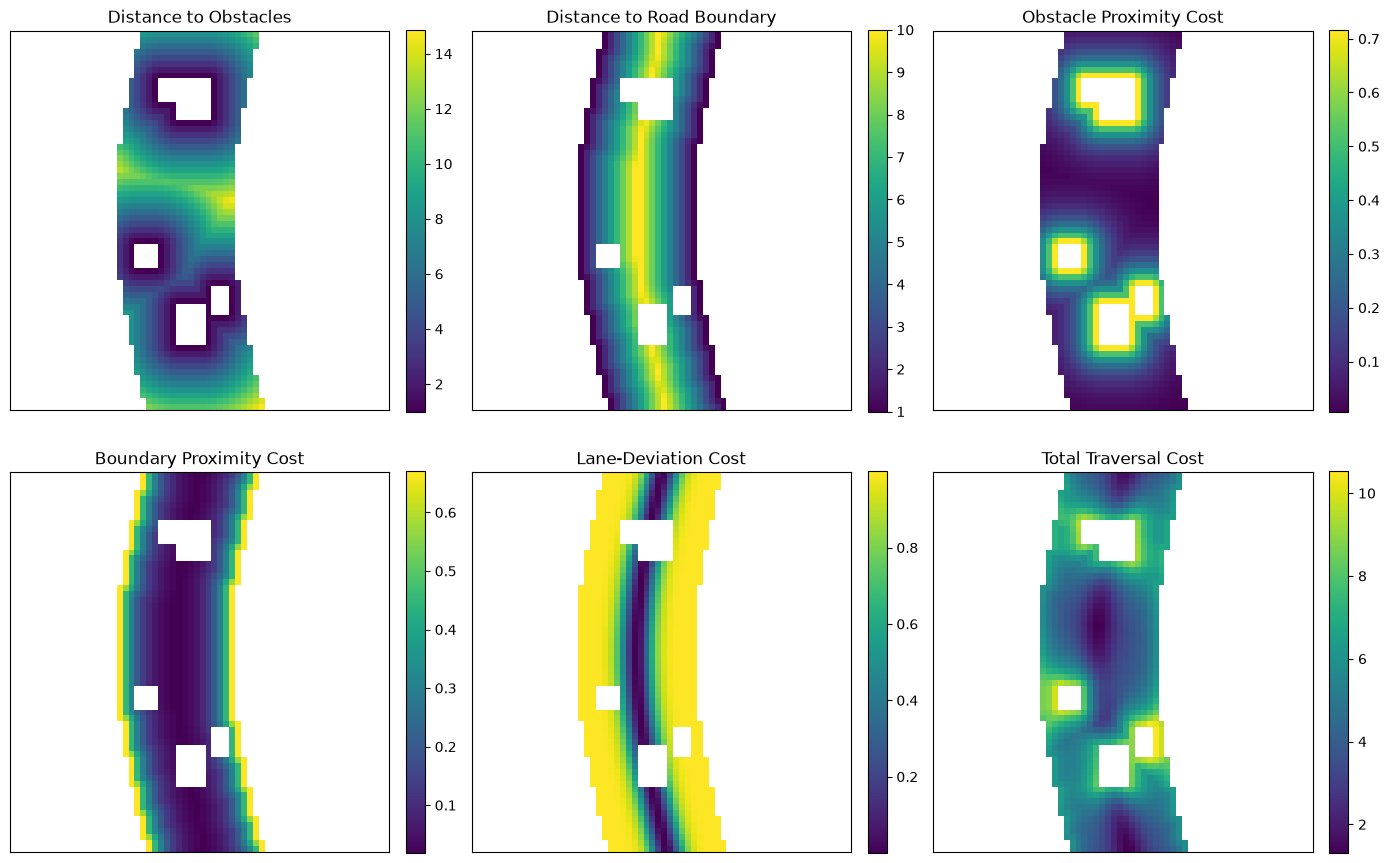

In [43]:
plot_safety_cost_maps(
    scene,
    safety_cost_maps,
)

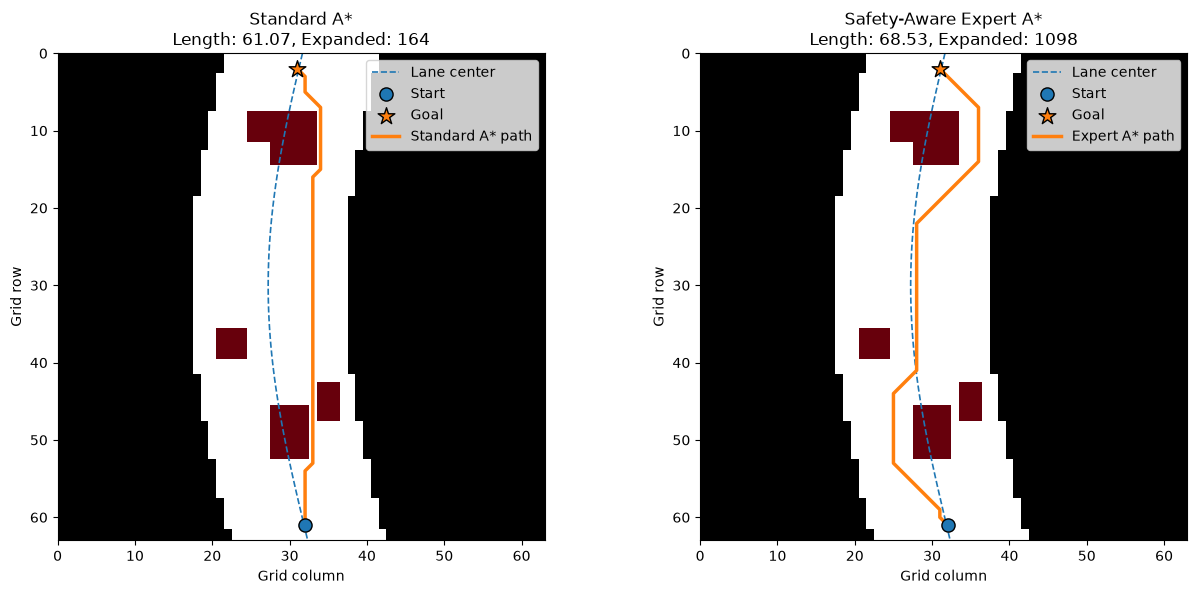

In [44]:
plot_path_comparison(
    scene,
    standard_result,
    expert_result,
)

In [45]:
standard_metrics = evaluate_path(
    scene=scene,
    path=standard_result.path,
)

expert_metrics = evaluate_path(
    scene=scene,
    path=expert_result.path,
)

print("Standard A* metrics")
print("-------------------")
print(
    "Path length:",
    f"{standard_metrics.path_length:.3f}",
)
print(
    "Minimum obstacle clearance:",
    f"{standard_metrics.minimum_obstacle_clearance:.3f}",
)
print(
    "Minimum boundary clearance:",
    f"{standard_metrics.minimum_boundary_clearance:.3f}",
)
print(
    "Mean lane deviation:",
    f"{standard_metrics.mean_lane_deviation:.3f}",
)
print(
    "Mean turn angle:",
    f"{standard_metrics.mean_turn_angle:.3f}",
)

print()

print("Safety-Aware Expert A* metrics")
print("------------------------------")
print(
    "Path length:",
    f"{expert_metrics.path_length:.3f}",
)
print(
    "Minimum obstacle clearance:",
    f"{expert_metrics.minimum_obstacle_clearance:.3f}",
)
print(
    "Minimum boundary clearance:",
    f"{expert_metrics.minimum_boundary_clearance:.3f}",
)
print(
    "Mean lane deviation:",
    f"{expert_metrics.mean_lane_deviation:.3f}",
)
print(
    "Mean turn angle:",
    f"{expert_metrics.mean_turn_angle:.3f}",
)

Standard A* metrics
-------------------
Path length: 61.071
Minimum obstacle clearance: 1.000
Minimum boundary clearance: 5.000
Mean lane deviation: 4.113
Mean turn angle: 0.095

Safety-Aware Expert A* metrics
------------------------------
Path length: 68.527
Minimum obstacle clearance: 2.236
Minimum boundary clearance: 3.000
Mean lane deviation: 2.715
Mean turn angle: 0.108


## 5. Batch Evaluation

The two planners are evaluated across multiple procedurally generated
scenes to determine whether the safety-aware behavior is consistent.

In [46]:
number_of_scenes = 100

standard_records = []
expert_records = []

for seed in range(number_of_scenes):
    test_scene = generate_driving_scene(seed=seed)

    test_standard_result = astar_search(
        free_space=test_scene.free_space,
        start=test_scene.start,
        goal=test_scene.goal,
    )

    test_cost_maps = build_safety_cost_maps(
        test_scene
    )

    test_expert_result = cost_aware_astar(
        free_space=test_scene.free_space,
        traversal_cost=test_cost_maps.traversal_cost,
        start=test_scene.start,
        goal=test_scene.goal,
    )

    standard_metric = evaluate_path(
        scene=test_scene,
        path=test_standard_result.path,
    )

    expert_metric = evaluate_path(
        scene=test_scene,
        path=test_expert_result.path,
    )

    standard_records.append(
        {
            "success": standard_metric.success,
            "path_length": standard_metric.path_length,
            "minimum_obstacle_clearance":
                standard_metric.minimum_obstacle_clearance,
            "minimum_boundary_clearance":
                standard_metric.minimum_boundary_clearance,
            "mean_lane_deviation":
                standard_metric.mean_lane_deviation,
            "mean_turn_angle":
                standard_metric.mean_turn_angle,
            "expanded_nodes":
                test_standard_result.expanded_nodes,
            "planning_time_ms":
                test_standard_result.planning_time * 1000,
        }
    )

    expert_records.append(
        {
            "success": expert_metric.success,
            "path_length": expert_metric.path_length,
            "minimum_obstacle_clearance":
                expert_metric.minimum_obstacle_clearance,
            "minimum_boundary_clearance":
                expert_metric.minimum_boundary_clearance,
            "mean_lane_deviation":
                expert_metric.mean_lane_deviation,
            "mean_turn_angle":
                expert_metric.mean_turn_angle,
            "expanded_nodes":
                test_expert_result.expanded_nodes,
            "planning_time_ms":
                test_expert_result.planning_time * 1000,
        }
    )

print(
    f"Evaluated {number_of_scenes} scenes."
)

Evaluated 100 scenes.


In [47]:
def summarize_records(
    records: list[dict],
) -> dict:
    """Calculate mean metrics over successful scenes."""
    successful_records = [
        record
        for record in records
        if record["success"]
    ]

    metric_names = [
        "path_length",
        "minimum_obstacle_clearance",
        "minimum_boundary_clearance",
        "mean_lane_deviation",
        "mean_turn_angle",
        "expanded_nodes",
        "planning_time_ms",
    ]

    summary = {
        "success_rate":
            len(successful_records) / len(records)
    }

    for metric_name in metric_names:
        values = np.asarray(
            [
                record[metric_name]
                for record in successful_records
            ],
            dtype=np.float64,
        )

        summary[metric_name] = float(
            np.mean(values)
        )

    return summary

In [48]:
standard_summary = summarize_records(
    standard_records
)

expert_summary = summarize_records(
    expert_records
)

print("Average results over 100 scenes")
print("=" * 67)

print(
    f"{'Metric':<30}"
    f"{'Standard A*':>18}"
    f"{'Expert A*':>18}"
)

print("-" * 67)

metrics_to_display = [
    ("Success rate", "success_rate"),
    ("Path length", "path_length"),
    (
        "Minimum obstacle clearance",
        "minimum_obstacle_clearance",
    ),
    (
        "Minimum boundary clearance",
        "minimum_boundary_clearance",
    ),
    (
        "Mean lane deviation",
        "mean_lane_deviation",
    ),
    (
        "Mean turn angle",
        "mean_turn_angle",
    ),
    ("Expanded nodes", "expanded_nodes"),
    ("Planning time (ms)", "planning_time_ms"),
]

for label, key in metrics_to_display:
    print(
        f"{label:<30}"
        f"{standard_summary[key]:>18.3f}"
        f"{expert_summary[key]:>18.3f}"
    )

Average results over 100 scenes
Metric                               Standard A*         Expert A*
-------------------------------------------------------------------
Success rate                               1.000             1.000
Path length                               61.203            63.092
Minimum obstacle clearance                 1.340             2.438
Minimum boundary clearance                 6.803             6.883
Mean lane deviation                        1.628             1.197
Mean turn angle                            0.064             0.156
Expanded nodes                           174.750           908.960
Planning time (ms)                         0.707             4.516


### Preliminary Analysis

Across 100 procedurally generated scenes, both planners achieved a
100% success rate. The safety-aware expert planner increased the
average minimum obstacle clearance from 1.340 to 2.438 grid cells and
reduced the mean lane deviation from 1.628 to 1.197 grid cells.

These safety improvements required only a small increase in average
path length, from 61.203 to 63.092 grid units. The minimum road-boundary
clearance was also maintained.

The expert planner expanded more nodes and required more planning time,
but its average runtime remained below 5 ms. Its mean turn angle was
higher than that of standard A*, indicating that explicit path
smoothness or turning penalties may be considered in future work.